## Analysis of Diamonds Dataset

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

# Define the paths
zip_file_path = '/content/diamonds.csv.zip'
csv_file_name = 'diamonds.csv'

# Check if the CSV file exists, if not, extract it from the zip
if not os.path.exists(csv_file_name):
    print(f"Extracting {csv_file_name} from {zip_file_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Extraction complete.")
else:
    print(f"{csv_file_name} already exists. Skipping extraction.")

# Read dataset
df_diamonds = pd.read_csv(
    csv_file_name,
    engine="python",
    on_bad_lines="skip"
)

print("First 5 Rows")
display(df_diamonds.head())

diamonds.csv already exists. Skipping extraction.
First 5 Rows


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
print("\nShape")
print(df_diamonds.shape)

print("\nData Types")
print(df_diamonds.dtypes)


Shape
(53940, 11)

Data Types
Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object


In [15]:
print("\nDescriptive Statistics")
display(df_diamonds.describe())


Descriptive Statistics


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Filtering Data

In [16]:
# Numerical columns
num_cols_diamonds = df_diamonds.select_dtypes(include="number").columns

# Filtering - using 'price' as a representative numerical column
if 'price' in num_cols_diamonds:
    filtered_diamonds = df_diamonds[df_diamonds['price'] > df_diamonds['price'].mean()]
    print("\nFiltered Data (Diamonds with price above average)")
    display(filtered_diamonds.head())
else:
    print("No 'price' column found for filtering.")


Filtered Data (Diamonds with price above average)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
5903,5904,0.90,Premium,H,VS2,62.6,58.0,3933,6.14,6.19,3.86
5904,5905,0.93,Very Good,G,SI1,62.5,57.8,3933,6.15,6.28,3.87
5905,5906,0.83,Ideal,D,SI1,61.5,53.0,3933,6.09,6.07,3.74
5906,5907,0.90,Good,E,SI1,60.8,65.0,3933,6.14,6.17,3.74
5907,5908,0.81,Ideal,F,VS1,61.5,55.0,3933,6.01,5.96,3.68


### Sorting Data

In [17]:
# Sorting - by 'carat' in descending order
if 'carat' in num_cols_diamonds:
    sorted_diamonds = df_diamonds.sort_values(by='carat', ascending=False)
    print("\nSorted Data (Diamonds by carat, descending)")
    display(sorted_diamonds.head())
else:
    print("No 'carat' column found for sorting.")


Sorted Data (Diamonds by carat, descending)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
27415,27416,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,27631,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
27130,27131,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
25999,26000,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
25998,25999,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17


### Statistical Analysis of Numerical Columns

In [18]:
for col in num_cols_diamonds:
    print("\nColumn:", col)
    print("Mean:", df_diamonds[col].mean())
    print("Median:", df_diamonds[col].median())
    # Mode might return multiple values, so take the first
    print("Mode:", df_diamonds[col].mode()[0])
    print("Standard Deviation:", df_diamonds[col].std())


Column: Unnamed: 0
Mean: 26970.5
Median: 26970.5
Mode: 1
Standard Deviation: 15571.281096942537

Column: carat
Mean: 0.7979397478680014
Median: 0.7
Mode: 0.3
Standard Deviation: 0.47401124440538067

Column: depth
Mean: 61.749404894327036
Median: 61.8
Mode: 62.0
Standard Deviation: 1.4326213188337733

Column: table
Mean: 57.45718390804598
Median: 57.0
Mode: 56.0
Standard Deviation: 2.234490562820938

Column: price
Mean: 3932.799721913237
Median: 2401.0
Mode: 605
Standard Deviation: 3989.4397381463023

Column: x
Mean: 5.731157211716722
Median: 5.7
Mode: 4.37
Standard Deviation: 1.1217607467924422

Column: y
Mean: 5.734525954764553
Median: 5.71
Mode: 4.34
Standard Deviation: 1.1421346741235396

Column: z
Mean: 3.5387337782721544
Median: 3.53
Mode: 2.7
Standard Deviation: 0.7056988469499964


### Grouping Data by Categorical Column

In [19]:
cat_cols_diamonds = df_diamonds.select_dtypes(include=object).columns # Use object for string-like categories

if 'cut' in cat_cols_diamonds and len(num_cols_diamonds) > 0:
    grouped_diamonds = df_diamonds.groupby('cut')[num_cols_diamonds].mean()
    print(f"\nGrouped Data by 'cut' (mean of numerical columns)")
    display(grouped_diamonds)
elif 'cut' not in cat_cols_diamonds:
    print("No 'cut' column found for grouping.")
else:
    print("No numerical columns found for grouping aggregation.")


Grouped Data by 'cut' (mean of numerical columns)


,Unnamed: 0,carat,depth,table,price,x,y,z
cut,,,,,,,,
Fair,24147.357764,1.046137,64.041677,59.053789,4358.757764,6.246894,6.182652,3.982770
Good,24774.931309,0.849185,62.365879,58.694639,3928.864452,5.838785,5.850744,3.639507
Ideal,29047.630736,0.702837,61.709401,55.951668,3457.541970,5.507451,5.520080,3.401448
Premium,25600.209049,0.891955,61.264673,58.746095,4584.257704,5.973887,5.944879,3.647124
Very Good,26097.313193,0.806381,61.818275,57.956150,3981.759891,5.740696,5.770026,3.559801


### Correlation Matrix

In [20]:
if len(num_cols_diamonds) > 1:
    corr_diamonds = df_diamonds[num_cols_diamonds].corr()
    print("\nCorrelation Matrix")
    display(corr_diamonds)
else:
    print("\nNot enough numerical columns to compute correlation matrix.")


Correlation Matrix


,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.377983,-0.034800,-0.100830,-0.306873,-0.405440,-0.395843,-0.399208
carat,-0.377983,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,-0.034800,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,-0.100830,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,-0.306873,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,-0.405440,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,-0.395843,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,-0.399208,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


### Visualizations

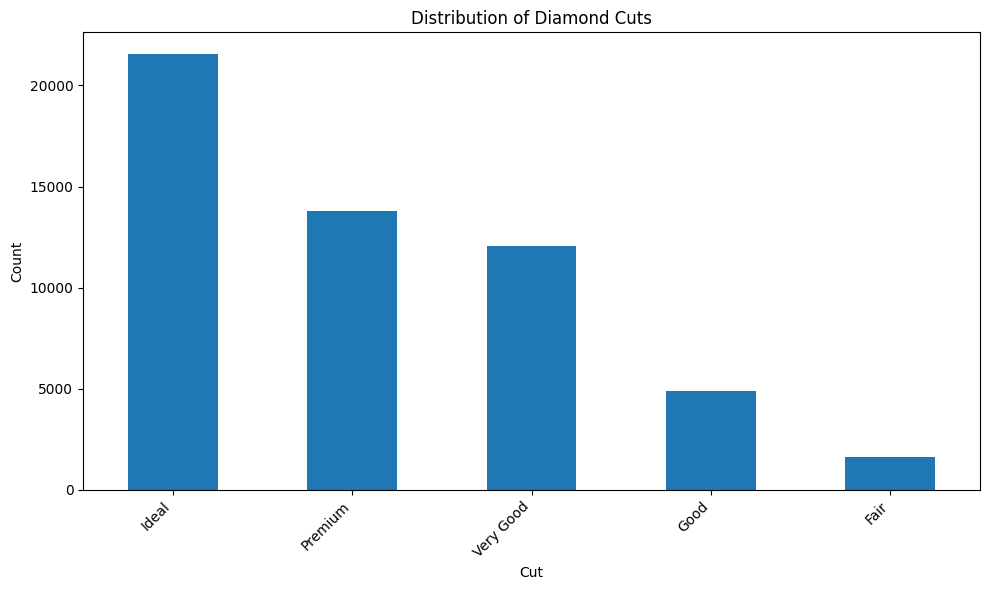

In [21]:
# Bar Chart - using 'cut' categories
if 'cut' in df_diamonds.columns:
    cut_counts = df_diamonds['cut'].value_counts().head(10)
    plt.figure(figsize=(10,6))
    cut_counts.plot(kind="bar")
    plt.title("Distribution of Diamond Cuts")
    plt.xlabel("Cut")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No 'cut' column for bar chart.")

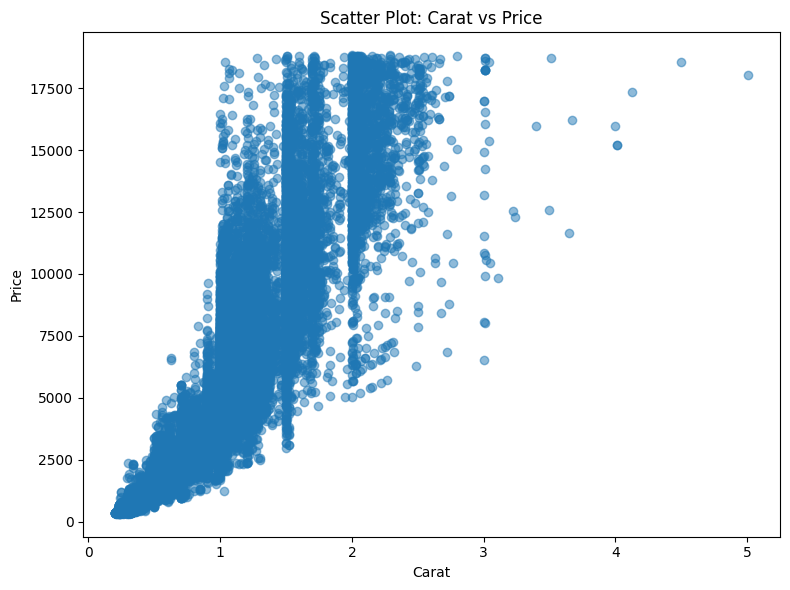

In [22]:
# Scatter Plot - 'carat' vs 'price'
if 'carat' in num_cols_diamonds and 'price' in num_cols_diamonds:
    plt.figure(figsize=(8,6))
    plt.scatter(
        df_diamonds['carat'],
        df_diamonds['price'],
        alpha=0.5
    )
    plt.xlabel("Carat")
    plt.ylabel("Price")
    plt.title("Scatter Plot: Carat vs Price")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns ('carat', 'price') for scatter plot.")